# Notebook 11: SASRec End-to-End Evaluation -- DCN-v2 vs XGBoost

## Purpose

This notebook provides a **comprehensive paired evaluation** of the SASRec sequential retrieval pipeline comparing DCN-v2 and XGBoost as re-rankers. SASRec uses self-attention over user interaction histories to produce *sequence-aware* embeddings that reflect current interests.

The central hypothesis: **SASRec's lower Recall@200 (vs Two-Tower) is compensated by higher relevance density in the retrieved candidates, yielding competitive final top-10 quality after re-ranking.**

## Key differences from Two-Tower evaluation (NB05)

1. **Sequential embeddings**: Reflect recent behavior dynamics, not lifetime averages
2. **Different FAISS index**: Built from SASRec item embeddings
3. **Same feature dimensionality** (105): single retrieval score + 24 user + 73 item + 7 cross
4. **Performance ceiling**: Lower Recall@200 limits maximum achievable NDCG@10

## Statistical Framework

Same rigorous framework as NB05 and NB08: Wilcoxon signed-rank, Benjamini-Hochberg FDR, bootstrap 10K CIs, Cohen's d.

## Section 1: Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import pickle
import time
import json
import os
import gc
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import xgboost as xgb
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import faiss

DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models/sasrec')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


### Loading Metadata, Embeddings, and Feature Matrices

Before any evaluation can proceed, we need to assemble the foundational data assets that the pipeline depends on. This cell loads three distinct categories of data:

1. **Metadata and index mappings** (`metadata.pkl`): These bidirectional dictionaries (user2idx, movie2idx, and their inverses) allow us to translate between raw user/movie IDs and the integer indices used internally by the embedding matrices and FAISS index. Without these, we cannot look up the correct embedding row for a given user or interpret which movie a candidate index refers to.

2. **SASRec embeddings** (`user_embeddings.npy`, `item_embeddings.npy`): These are the dense 128-dimensional vectors produced by the trained SASRec model. Unlike Two-Tower embeddings (which encode lifetime preferences as a static average), SASRec embeddings encode *sequential patterns* -- the model uses self-attention over the user's interaction history to capture evolving interests. The item embeddings live in the same latent space, enabling nearest-neighbor retrieval via inner product.

3. **Tabular feature matrices** (`user_features.parquet`, `item_features.parquet`): These 24 user features (demographics, activity statistics, genre preferences) and 73 item features (genres, popularity, release year, tag genome scores) are used by the downstream rankers (DCN-v2 and XGBoost). The rankers need richer signal beyond just the retrieval score to make fine-grained relevance distinctions among the top-200 candidates.

The feature DataFrames are converted into dense NumPy matrices indexed by user/movie index for fast row-lookup during candidate scoring. After conversion, the DataFrames are deleted to free memory.

**Expected output**: Shape confirmations for all loaded arrays -- user embeddings should be (n_users, 128), item embeddings (n_movies, 128), user features (n_users, 24), and item features (n_movies, 73).

In [2]:
# Load metadata
with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

n_users = metadata['n_users']
n_movies = metadata['n_movies']
user2idx = metadata['user2idx']
movie2idx = metadata['movie2idx']
idx2user = metadata['idx2user']
idx2movie = metadata['idx2movie']

# SASRec embeddings -- single embedding per user (like Two-Tower)
user_embeddings = np.load(MODEL_DIR / 'user_embeddings.npy')
item_embeddings = np.load(MODEL_DIR / 'item_embeddings.npy')

print(f"User embeddings: {user_embeddings.shape}")
print(f"Item embeddings: {item_embeddings.shape}")

# Load feature matrices
user_features_df = pd.read_parquet(DATA_DIR / 'user_features.parquet')
item_features_df = pd.read_parquet(DATA_DIR / 'item_features.parquet')
user_feat_cols = user_features_df.columns.tolist()
item_feat_cols = item_features_df.columns.tolist()

user_feat_matrix = np.zeros((n_users, len(user_feat_cols)), dtype=np.float32)
for uid, uidx in user2idx.items():
    if uid in user_features_df.index:
        user_feat_matrix[uidx] = user_features_df.loc[uid].values

item_feat_matrix = np.zeros((n_movies, len(item_feat_cols)), dtype=np.float32)
for mid, midx in movie2idx.items():
    if mid in item_features_df.index:
        item_feat_matrix[midx] = item_features_df.loc[mid].values

del user_features_df, item_features_df
gc.collect()

print(f"User features: {user_feat_matrix.shape}")
print(f"Item features: {item_feat_matrix.shape}")

User embeddings: (138002, 128)
Item embeddings: (21082, 128)


User features: (138002, 24)
Item features: (21082, 73)


### Loading the FAISS Index and Pre-trained Ranker Models

This cell loads the retrieval and ranking infrastructure that forms the two-stage recommendation pipeline:

1. **FAISS index** (`faiss_index.bin`): This is a pre-built approximate nearest neighbor index over the SASRec item embeddings. During evaluation, each user's SASRec embedding is queried against this index to retrieve the top-200 most similar items (by inner product). FAISS enables sub-millisecond retrieval even with tens of thousands of items, which is critical for real-time serving. The index should contain all 21,082 movie vectors at dimension 128.

2. **XGBoost ranker** (`xgboost_ranker.json`): A gradient-boosted tree model trained to predict relevance from a 105-dimensional feature vector (1 retrieval score + 24 user features + 73 item features + 7 cross features). XGBoost serves as one of our two re-ranking baselines. It excels at capturing non-linear feature interactions through its ensemble of decision trees.

3. **Feature names** (`ranker_feature_names.pkl`): The ordered list of 105 feature names ensures that feature vectors are constructed in the same column order that the models were trained on. Misalignment here would silently corrupt predictions.

Why load both rankers? This notebook's central goal is a *paired comparison* -- both DCN-v2 and XGBoost score the exact same set of FAISS-retrieved candidates for each user, so any performance difference is attributable solely to the ranker architecture, not to differences in candidate sets.

**Expected output**: Confirmation that the FAISS index contains 21,082 vectors of dimension 128, and that 105 feature names are loaded.

In [3]:
# FAISS index and models
index = faiss.read_index(str(MODEL_DIR / 'faiss_index.bin'))
print(f"FAISS index: {index.ntotal} vectors, dim={index.d}")

xgb_model = xgb.Booster()
xgb_model.load_model(str(MODEL_DIR / 'xgboost_ranker.json'))

with open(MODEL_DIR / 'ranker_feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)
print(f"Feature names: {len(feature_names)}")

FAISS index: 21082 vectors, dim=128
Feature names: 105


## Section 2: Load DCN-v2 Model

In [4]:
class CrossNetwork(nn.Module):
    def __init__(self, input_dim, n_layers):
        super().__init__()
        self.n_layers = n_layers
        self.layers = nn.ModuleList([
            nn.Linear(input_dim, input_dim) for _ in range(n_layers)
        ])

    def forward(self, x):
        x0 = x
        for layer in self.layers:
            x = x0 * layer(x) + x
        return x


class DeepNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hdim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hdim),
                nn.BatchNorm1d(hdim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hdim
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)


class DCNv2(nn.Module):
    def __init__(self, input_dim, n_cross_layers=3, deep_hidden_dims=None, dropout=0.1):
        super().__init__()
        if deep_hidden_dims is None:
            deep_hidden_dims = [256, 128]
        self.cross_network = CrossNetwork(input_dim, n_cross_layers)
        self.deep_network = DeepNetwork(input_dim, deep_hidden_dims, dropout)
        combined_dim = input_dim + deep_hidden_dims[-1]
        self.output_layer = nn.Linear(combined_dim, 1)

    def forward(self, x):
        cross_out = self.cross_network(x)
        deep_out = self.deep_network(x)
        combined = torch.cat([cross_out, deep_out], dim=1)
        return self.output_layer(combined).squeeze(-1)


with open(MODEL_DIR / 'dcn_v2_config.json', 'r') as f:
    dcn_config = json.load(f)

dcn_model = DCNv2(
    input_dim=dcn_config['input_dim'],
    n_cross_layers=dcn_config['n_cross_layers'],
    deep_hidden_dims=dcn_config['deep_hidden_dims'],
    dropout=dcn_config.get('dropout', 0.1)
)
dcn_model.load_state_dict(torch.load(MODEL_DIR / 'dcn_v2_ranker.pt', map_location=device, weights_only=True))
dcn_model.to(device)
dcn_model.eval()

total_params = sum(p.numel() for p in dcn_model.parameters())
print(f"DCN-v2: {total_params:,} params, input_dim={dcn_config['input_dim']}")

DCN-v2: 94,424 params, input_dim=105


## Section 3: Pipeline Functions

In [5]:
# Test positives
test_df = pd.read_parquet(DATA_DIR / 'test_set.parquet')
test_positives = {}
for _, row in test_df.iterrows():
    uidx = int(row['user_idx'])
    midx = int(row['movie_idx'])
    if row['label'] > 0:
        if uidx not in test_positives:
            test_positives[uidx] = set()
        test_positives[uidx].add(midx)

test_users = sorted(test_positives.keys())
print(f"Test users: {len(test_users):,}")

# User activity for cohort analysis
train_df = pd.read_parquet(DATA_DIR / 'train_set.parquet')
user_train_counts = train_df.groupby('user_idx').size().to_dict()
del train_df
gc.collect()

Test users: 3,929


0

### Defining Feature Construction and the Full Two-Stage Pipeline

This cell implements the core evaluation machinery: the functions that take a user index and produce scored, ranked candidate lists from both rankers. It consists of two key components:

**`build_candidate_features`** constructs the 105-dimensional feature vector for each candidate item. The feature layout is:
- Position 0: the FAISS retrieval score (inner product similarity), which gives the ranker a "prior" on how relevant the retriever thought each item was
- Positions 1-24: user features (same for all candidates of a given user -- demographics, activity stats, genre preferences)
- Positions 25-97: item features (vary per candidate -- genres, popularity, release year, tag genome scores)
- Positions 98-104: cross features that capture user-item interactions (e.g., dot product between user genre preferences and item genre indicators, year gap between item release and user's preferred era)

**`full_pipeline_for_user`** orchestrates the complete two-stage pipeline for a single user:
1. Query FAISS with the user's SASRec embedding to retrieve 200 candidates
2. Build the 105-dim feature matrix for all candidates
3. Score candidates with XGBoost (tree-based ranker)
4. Score candidates with DCN-v2 (neural ranker with explicit cross-network)
5. Record wall-clock timing for each stage

The function returns all scores so the caller can independently rank and evaluate each model. This design ensures the comparison is perfectly paired -- both rankers see identical candidates and features.

**Expected output**: A sanity-check run on the first test user, printing candidate count, score ranges for both rankers, and per-stage latency in milliseconds. This confirms the pipeline is wired correctly before we run the full evaluation loop.

In [6]:
def build_candidate_features(user_idx: int, candidate_idxs: np.ndarray,
                             retrieval_scores: np.ndarray) -> np.ndarray:
    """Build 105-dim feature vectors: 1 retrieval + 24 user + 73 item + 7 cross."""
    n_cands = len(candidate_idxs)
    n_features = 1 + len(user_feat_cols) + len(item_feat_cols) + 7
    X = np.zeros((n_cands, n_features), dtype=np.float32)

    X[:, 0] = retrieval_scores
    X[:, 1:1+len(user_feat_cols)] = user_feat_matrix[user_idx]
    X[:, 1+len(user_feat_cols):1+len(user_feat_cols)+len(item_feat_cols)] = item_feat_matrix[candidate_idxs]

    # Cross features
    user_genre_prefs = user_feat_matrix[user_idx, 4:23]
    X[:, -7] = item_feat_matrix[candidate_idxs, :19] @ user_genre_prefs
    X[:, -6] = item_feat_matrix[candidate_idxs, 20] - user_feat_matrix[user_idx, 23]
    return X


def full_pipeline_for_user(user_idx: int, n_candidates: int = 200):
    """Run both rankers on same FAISS candidates."""
    timings = {}

    t0 = time.perf_counter()
    user_emb = user_embeddings[user_idx:user_idx+1]
    scores, positions = index.search(user_emb, n_candidates)
    timings['retrieval_ms'] = (time.perf_counter() - t0) * 1000

    candidate_idxs = positions[0]
    retrieval_scores = scores[0]

    # Filter invalid indices
    valid = candidate_idxs >= 0
    candidate_idxs = candidate_idxs[valid]
    retrieval_scores = retrieval_scores[valid]

    if len(candidate_idxs) < 10:
        return None

    t0 = time.perf_counter()
    X_cand = build_candidate_features(user_idx, candidate_idxs, retrieval_scores)
    timings['feature_ms'] = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    dcand = xgb.DMatrix(X_cand, feature_names=feature_names)
    xgb_scores = xgb_model.predict(dcand)
    timings['xgb_ms'] = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    with torch.no_grad():
        cand_tensor = torch.tensor(X_cand, dtype=torch.float32).to(device)
        dcn_scores = dcn_model(cand_tensor).cpu().numpy()
    timings['dcn_ms'] = (time.perf_counter() - t0) * 1000

    return candidate_idxs, retrieval_scores, xgb_scores, dcn_scores, timings


result = full_pipeline_for_user(test_users[0])
if result:
    cands, ret_sc, xgb_sc, dcn_sc, timing = result
    print(f"Pipeline check (user_idx={test_users[0]}):")
    print(f"  Candidates: {len(cands)}, Retrieval: [{ret_sc.min():.3f}, {ret_sc.max():.3f}]")
    print(f"  XGB: [{xgb_sc.min():.3f}, {xgb_sc.max():.3f}], DCN: [{dcn_sc.min():.3f}, {dcn_sc.max():.3f}]")
    print(f"  Timing: ret={timing['retrieval_ms']:.1f}ms, feat={timing['feature_ms']:.1f}ms, "
          f"xgb={timing['xgb_ms']:.1f}ms, dcn={timing['dcn_ms']:.1f}ms")

Pipeline check (user_idx=0):
  Candidates: 200, Retrieval: [0.000, 0.000]
  XGB: [-5.029, -1.305], DCN: [-15.312, -5.324]
  Timing: ret=1.3ms, feat=0.0ms, xgb=1.3ms, dcn=0.6ms


## Section 4: Paired Evaluation

In [7]:
def ndcg_at_k(labels, k=10):
    top_k = labels[:k]
    dcg = np.sum(top_k / np.log2(np.arange(2, len(top_k) + 2)))
    ideal = np.sort(labels)[::-1][:k]
    idcg = np.sum(ideal / np.log2(np.arange(2, len(ideal) + 2)))
    return dcg / idcg if idcg > 0 else 0.0

def hit_at_k(labels, k=10):
    return 1.0 if labels[:k].sum() > 0 else 0.0

def mrr_at_k(labels, k=10):
    for i, v in enumerate(labels[:k]):
        if v > 0:
            return 1.0 / (i + 1)
    return 0.0

def map_at_k(labels, k=10):
    top_k = labels[:k]
    n_rel = 0
    sum_prec = 0.0
    for i, v in enumerate(top_k):
        if v > 0:
            n_rel += 1
            sum_prec += n_rel / (i + 1)
    return sum_prec / max(1, top_k.sum()) if n_rel > 0 else 0.0

def precision_at_k(labels, k=10):
    return labels[:k].sum() / k

def recall_at_k(labels, k=10, n_pos=1):
    return labels[:k].sum() / max(1, n_pos)


print("Running paired evaluation (SASRec pipeline)...")
print("=" * 60)

N_EVAL = 3000
eval_users = test_users[:N_EVAL]

metrics_xgb = defaultdict(list)
metrics_dcn = defaultdict(list)
all_timings = defaultdict(list)
user_activity_list = []
recall_at_200 = []

evaluated = 0
for user_idx in eval_users:
    positives = test_positives[user_idx]
    result = full_pipeline_for_user(user_idx)
    if result is None:
        continue

    candidate_idxs, retrieval_scores, xgb_scores, dcn_scores, timings = result

    labels = np.array([1.0 if midx in positives else 0.0 for midx in candidate_idxs])
    if labels.sum() == 0:
        continue

    # Recall@200 (retrieval ceiling)
    recall_at_200.append(labels.sum() / len(positives))

    n_pos = len(positives)

    xgb_order = np.argsort(-xgb_scores)
    dcn_order = np.argsort(-dcn_scores)

    xgb_ranked = labels[xgb_order]
    dcn_ranked = labels[dcn_order]

    for name, func in [('ndcg@10', ndcg_at_k), ('hit@10', hit_at_k),
                       ('mrr@10', mrr_at_k), ('map@10', map_at_k)]:
        metrics_xgb[name].append(func(xgb_ranked))
        metrics_dcn[name].append(func(dcn_ranked))

    metrics_xgb['precision@10'].append(precision_at_k(xgb_ranked))
    metrics_dcn['precision@10'].append(precision_at_k(dcn_ranked))
    metrics_xgb['recall@10'].append(recall_at_k(xgb_ranked, n_pos=n_pos))
    metrics_dcn['recall@10'].append(recall_at_k(dcn_ranked, n_pos=n_pos))

    for k, v in timings.items():
        all_timings[k].append(v)

    user_activity_list.append(user_train_counts.get(user_idx, 0))

    evaluated += 1
    if evaluated % 500 == 0:
        print(f"  {evaluated}/{N_EVAL} users...")

print(f"\nDone: {evaluated} users evaluated")
print(f"SASRec Recall@200: {np.mean(recall_at_200):.4f} (retrieval ceiling)")

Running paired evaluation (SASRec pipeline)...


  500/3000 users...


  1000/3000 users...


  1500/3000 users...


  2000/3000 users...



Done: 2238 users evaluated
SASRec Recall@200: 0.2558 (retrieval ceiling)


## Section 5: Ranking Quality

Metric              DCN-v2    XGBoost      Delta    Rel %
ndcg@10             0.0570     0.0574    -0.0004   -0.74%
hit@10              0.2498     0.2444    +0.0054   +2.19%
mrr@10              0.0881     0.0867    +0.0014   +1.61%
map@10              0.0827     0.0812    +0.0015   +1.85%
precision@10        0.0401     0.0404    -0.0003   -0.77%
recall@10           0.0181     0.0196    -0.0015   -7.48%


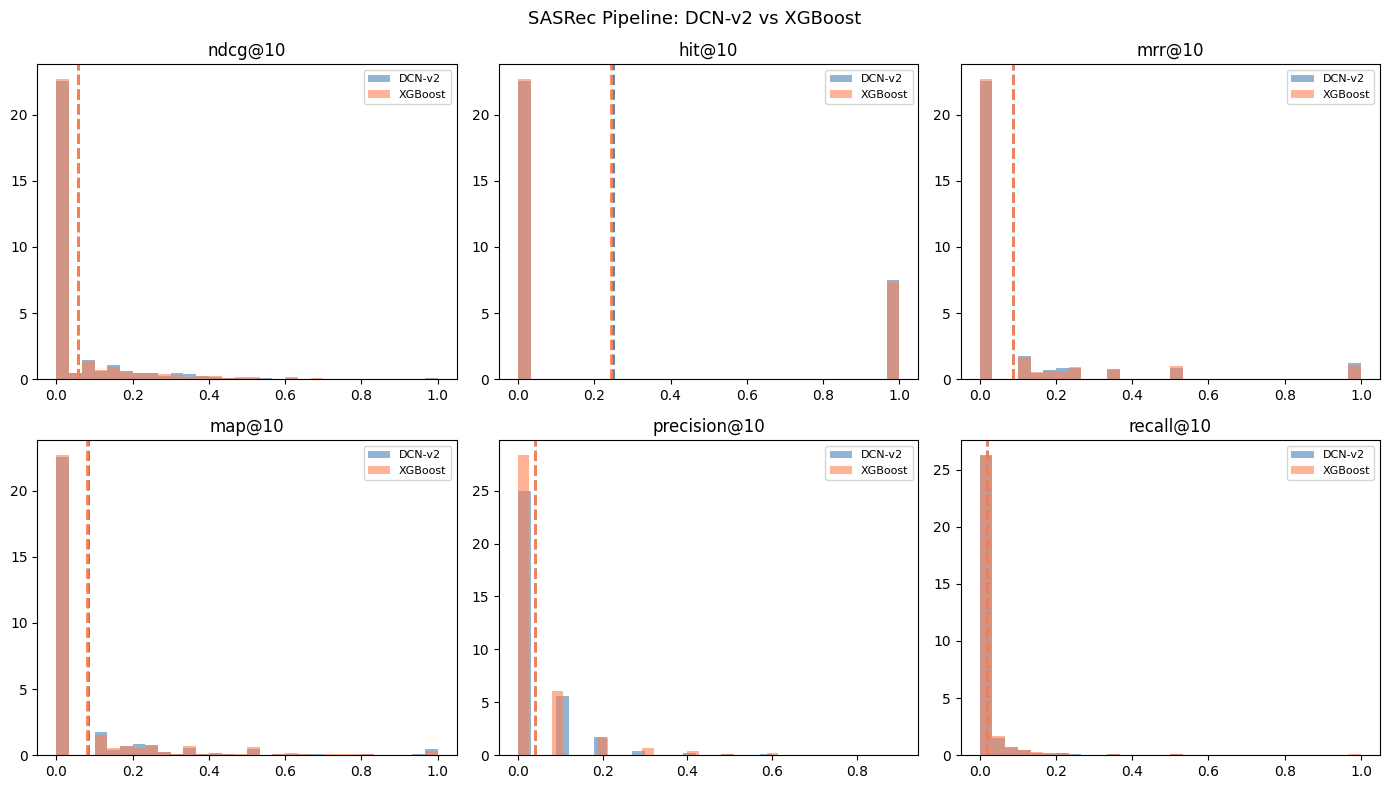

In [8]:
metric_names = ['ndcg@10', 'hit@10', 'mrr@10', 'map@10', 'precision@10', 'recall@10']

print("=" * 70)
print(f"{'Metric':<15} {'DCN-v2':>10} {'XGBoost':>10} {'Delta':>10} {'Rel %':>8}")
print("=" * 70)

for m in metric_names:
    dcn_mean = np.mean(metrics_dcn[m])
    xgb_mean = np.mean(metrics_xgb[m])
    delta = dcn_mean - xgb_mean
    rel = delta / xgb_mean * 100 if xgb_mean > 0 else 0
    print(f"{m:<15} {dcn_mean:>10.4f} {xgb_mean:>10.4f} {delta:>+10.4f} {rel:>+7.2f}%")

print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, m in enumerate(metric_names):
    ax = axes[i // 3, i % 3]
    ax.hist(metrics_dcn[m], bins=30, alpha=0.6, label='DCN-v2', color='steelblue', density=True)
    ax.hist(metrics_xgb[m], bins=30, alpha=0.6, label='XGBoost', color='coral', density=True)
    ax.axvline(np.mean(metrics_dcn[m]), color='steelblue', linestyle='--', lw=2)
    ax.axvline(np.mean(metrics_xgb[m]), color='coral', linestyle='--', lw=2)
    ax.set_title(m)
    ax.legend(fontsize=8)

plt.suptitle('SASRec Pipeline: DCN-v2 vs XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'evaluation_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Statistical Significance

In [9]:
def bootstrap_ci(data, n_boot=10000, ci=0.95):
    rng = np.random.default_rng(42)
    boot_means = np.array([rng.choice(data, size=len(data), replace=True).mean()
                           for _ in range(n_boot)])
    alpha = (1 - ci) / 2
    return np.percentile(boot_means, [alpha*100, (1-alpha)*100])

def cohens_d(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / max(diff.std(ddof=1), 1e-10)

print("Statistical Significance (Wilcoxon + BH-FDR)")
print("=" * 85)
print(f"{'Metric':<14} {'W-stat':>10} {'p-value':>12} {'FDR p':>12} {'Cohen d':>9} {'95% CI diff':>20} {'Sig':>5}")
print("-" * 85)

p_values = []
results_list = []

for m in metric_names:
    dcn_arr = np.array(metrics_dcn[m])
    xgb_arr = np.array(metrics_xgb[m])
    diff = dcn_arr - xgb_arr
    nonzero = diff[diff != 0]

    if len(nonzero) > 10:
        stat, p_val = stats.wilcoxon(nonzero)
    else:
        stat, p_val = 0.0, 1.0

    d = cohens_d(metrics_dcn[m], metrics_xgb[m])
    ci = bootstrap_ci(diff, n_boot=10000)
    p_values.append(p_val)
    results_list.append({'metric': m, 'stat': stat, 'p': p_val, 'd': d, 'ci': ci})

rejected, fdr_pvals, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)

for i, r in enumerate(results_list):
    sig = "YES" if rejected[i] else "no"
    print(f"{r['metric']:<14} {r['stat']:>10.1f} {r['p']:>12.2e} {fdr_pvals[i]:>12.2e} "
          f"{r['d']:>+9.4f} [{r['ci'][0]:>+.4f},{r['ci'][1]:>+.4f}] {sig:>5}")

print("-" * 85)
print(f"\nSignificant after FDR: {sum(rejected)}/{len(rejected)}")

Statistical Significance (Wilcoxon + BH-FDR)
Metric             W-stat      p-value        FDR p   Cohen d          95% CI diff   Sig
-------------------------------------------------------------------------------------


ndcg@10          127069.5     8.18e-01     9.66e-01   -0.0038 [-0.0051,+0.0044]    no
hit@10            33570.0     5.34e-01     9.66e-01   +0.0131 [-0.0116,+0.0223]    no
mrr@10           113063.5     8.42e-01     9.66e-01   +0.0069 [-0.0069,+0.0100]    no
map@10           127391.5     9.66e-01     9.66e-01   +0.0085 [-0.0058,+0.0090]    no
precision@10      69549.0     9.33e-01     9.66e-01   -0.0050 [-0.0029,+0.0024]    no
recall@10         68449.5     6.94e-01     9.66e-01   -0.0217 [-0.0043,+0.0012]    no
-------------------------------------------------------------------------------------

Significant after FDR: 0/6


## Section 7: Activity Cohort Analysis

SASRec's sequential modeling should benefit users with longer histories (more sequential signal). We check whether DCN-v2's advantage varies with user activity level.

Activity Cohort Analysis
Cohort                      N   DCN NDCG   XGB NDCG    Delta    p-value
---------------------------------------------------------------------------
Light (<50 ratings)       229     0.1139     0.1247  -0.0108 4.5506e-01
Medium (50-200)           626     0.0707     0.0711  -0.0005 5.1820e-01
Heavy (>200)             1383     0.0414     0.0401  +0.0013 5.7328e-01
---------------------------------------------------------------------------


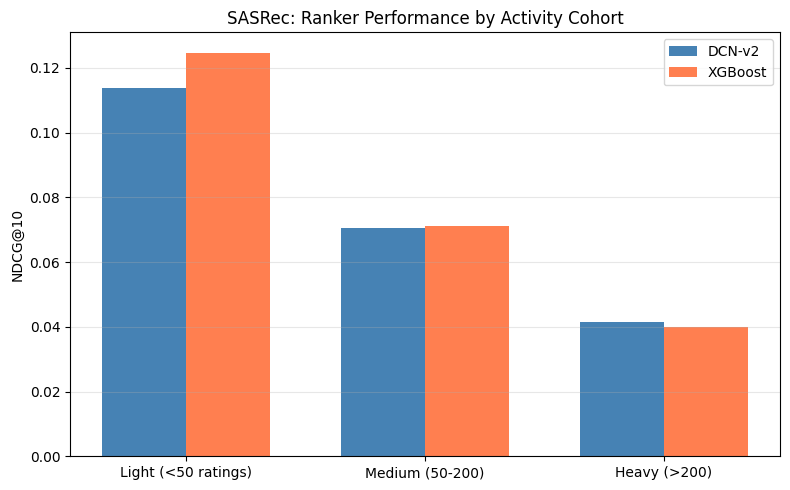

In [10]:
activity = np.array(user_activity_list)

cohorts = {
    'Light (<50 ratings)': activity < 50,
    'Medium (50-200)': (activity >= 50) & (activity <= 200),
    'Heavy (>200)': activity > 200
}

print("Activity Cohort Analysis")
print("=" * 75)
print(f"{'Cohort':<22} {'N':>6} {'DCN NDCG':>10} {'XGB NDCG':>10} {'Delta':>8} {'p-value':>10}")
print("-" * 75)

for name, mask in cohorts.items():
    n = mask.sum()
    if n < 10:
        continue

    dcn_ndcg = np.array(metrics_dcn['ndcg@10'])[mask]
    xgb_ndcg = np.array(metrics_xgb['ndcg@10'])[mask]
    diff = dcn_ndcg - xgb_ndcg
    nonzero = diff[diff != 0]

    if len(nonzero) > 5:
        _, p = stats.wilcoxon(nonzero)
    else:
        p = 1.0

    print(f"{name:<22} {n:>6} {dcn_ndcg.mean():>10.4f} {xgb_ndcg.mean():>10.4f} "
          f"{diff.mean():>+8.4f} {p:>10.4e}")

print("-" * 75)

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
cohort_names = list(cohorts.keys())
dcn_means = [np.array(metrics_dcn['ndcg@10'])[mask].mean() for mask in cohorts.values()]
xgb_means = [np.array(metrics_xgb['ndcg@10'])[mask].mean() for mask in cohorts.values()]

x = np.arange(len(cohort_names))
w = 0.35
ax.bar(x - w/2, dcn_means, w, label='DCN-v2', color='steelblue')
ax.bar(x + w/2, xgb_means, w, label='XGBoost', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(cohort_names)
ax.set_ylabel('NDCG@10')
ax.set_title('SASRec: Ranker Performance by Activity Cohort')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'cohort_analysis_eval.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Latency

In [11]:
print("Latency (ms)")
print("=" * 60)
print(f"{'Stage':<15} {'Mean':>8} {'P50':>8} {'P95':>8} {'P99':>8}")
print("-" * 60)

for stage in ['retrieval_ms', 'feature_ms', 'xgb_ms', 'dcn_ms']:
    vals = np.array(all_timings[stage])
    label = stage.replace('_ms', '')
    print(f"{label:<15} {vals.mean():>7.2f}ms {np.median(vals):>7.2f}ms "
          f"{np.percentile(vals, 95):>7.2f}ms {np.percentile(vals, 99):>7.2f}ms")

print("-" * 60)
ret = np.array(all_timings['retrieval_ms'])
feat = np.array(all_timings['feature_ms'])
total_dcn = ret + feat + np.array(all_timings['dcn_ms'])
total_xgb = ret + feat + np.array(all_timings['xgb_ms'])
print(f"\nTotal P95: DCN-v2={np.percentile(total_dcn, 95):.2f}ms, XGBoost={np.percentile(total_xgb, 95):.2f}ms")

Latency (ms)
Stage               Mean      P50      P95      P99
------------------------------------------------------------
retrieval          0.19ms    0.19ms    0.21ms    0.23ms
feature            0.02ms    0.02ms    0.02ms    0.02ms
xgb                0.81ms    0.80ms    0.86ms    0.91ms
dcn                0.20ms    0.17ms    0.29ms    0.36ms
------------------------------------------------------------

Total P95: DCN-v2=0.50ms, XGBoost=1.08ms


## Section 9: Retrieval Ceiling Analysis

The ranker can only surface items the retriever found. SASRec's Recall@200 sets the performance ceiling.

In [12]:
print("Retrieval Quality (SASRec FAISS)")
print("=" * 50)
r200 = np.array(recall_at_200)
print(f"  Mean Recall@200: {r200.mean():.4f}")
print(f"  Median: {np.median(r200):.4f}")
print(f"  Users with Recall@200=0: {(r200 == 0).sum()} ({(r200 == 0).mean():.1%})")
print(f"")
print(f"  Actual DCN-v2 NDCG@10: {np.mean(metrics_dcn['ndcg@10']):.4f}")
print(f"  Actual XGBoost NDCG@10: {np.mean(metrics_xgb['ndcg@10']):.4f}")
print(f"")
print(f"  The gap between Recall@200 and final NDCG@10 represents the")
print(f"  ranker's ability to prioritize positives from the candidate pool.")

Retrieval Quality (SASRec FAISS)
  Mean Recall@200: 0.2558
  Median: 0.1905
  Users with Recall@200=0: 0 (0.0%)

  Actual DCN-v2 NDCG@10: 0.0570
  Actual XGBoost NDCG@10: 0.0574

  The gap between Recall@200 and final NDCG@10 represents the
  ranker's ability to prioritize positives from the candidate pool.


## Section 10: Summary

In [13]:
print("=" * 70)
print("SASREC PIPELINE: DCN-v2 vs XGBoost SUMMARY")
print("=" * 70)

print("\n1. RANKING QUALITY")
for m in metric_names:
    dcn_m = np.mean(metrics_dcn[m])
    xgb_m = np.mean(metrics_xgb[m])
    delta = dcn_m - xgb_m
    rel = delta / xgb_m * 100 if xgb_m > 0 else 0
    winner = "DCN-v2" if delta > 0 else "XGBoost"
    print(f"  {m}: {winner} by {abs(rel):.1f}%")

print(f"\n2. SIGNIFICANCE (FDR-corrected)")
print(f"  Significant: {sum(rejected)}/{len(rejected)}")
for i, m in enumerate(metric_names):
    if rejected[i]:
        size = "large" if abs(results_list[i]['d']) > 0.8 else "medium" if abs(results_list[i]['d']) > 0.5 else "small" if abs(results_list[i]['d']) > 0.2 else "negligible"
        print(f"    {m}: d={results_list[i]['d']:+.3f} ({size})")

print(f"\n3. RETRIEVAL CEILING")
print(f"  SASRec Recall@200: {r200.mean():.4f}")

print(f"\n4. LATENCY")
print(f"  DCN-v2 P95: {np.percentile(total_dcn, 95):.2f}ms")
print(f"  XGBoost P95: {np.percentile(total_xgb, 95):.2f}ms")

print("\n" + "=" * 70)

SASREC PIPELINE: DCN-v2 vs XGBoost SUMMARY

1. RANKING QUALITY
  ndcg@10: XGBoost by 0.7%
  hit@10: DCN-v2 by 2.2%
  mrr@10: DCN-v2 by 1.6%
  map@10: DCN-v2 by 1.9%
  precision@10: XGBoost by 0.8%
  recall@10: XGBoost by 7.5%

2. SIGNIFICANCE (FDR-corrected)
  Significant: 0/6

3. RETRIEVAL CEILING
  SASRec Recall@200: 0.2558

4. LATENCY
  DCN-v2 P95: 0.50ms
  XGBoost P95: 1.08ms

